# 1 - Vetores, Escalares e Espaços Vetoriais

Uma feature é um dado bruto numérico, textual, ordinal, categórico, etc, tendo valores diferentes entre instâncias. O conjunto de todas as features e seus valores vai definir cada instância, tendo a possibilidade de diferenciar uma das outras ou reiterar padrões que podem ser explorados na criação do modelo.
Mas como dados geralmente podem vir de fontes ruins ou incompletas; ter variáveis cuja a escala de uma é drasticamente diferente da outra o'que afeta o cálculo de coeficientes; e tem dados que não são numéricos, é importante que as instâncias sejam verificadas, as features sejam normalizadas e dados convertidos para números antes de serem processados. Isso são 3 de vários outros problemas de tratamento que aflige o processo.


Há métodos para selecionar features que possam ajudar melhor no desempenho do nosso modelo, por exemplo filtragem que mede a importância das features com base em medidas estatísticas como a variância, colinearidade com outras features, e qualquer outra medida que é independente do modelo. O wrapper visa testar conjuntos diferentes de features com um modelo e medir a importância das features com base no resultado desses testes. O embedded por sua vez mede a importância das features enquanto o modelo é treinado, acelerando o processo e personalizando as features para o modelo usado.


Escalares são unidades matemáticas que por si só representam um número. Os vetores são por si só conjuntos de vários escalares, e na álgebra linear são pontos em um espaço vetorial, sua posição varia de acordo com os escalares que o compõem. Os espaços vetoriais são espaços N-dimensionais que acomodam vetores e podem ser visualizados de qualquer forma ou abstraídos, contanto que sigam alguns axiomas, por exemplo :

<img src="https://i.imgur.com/MAvL78Z.png">

(https://www.3blue1brown.com/lessons/abstract-vector-spaces)


Agora vamos ver um exemplo desses conceitos aplicados em uma analise de dados sobre marcas de carro.
<img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*pMPGB9NXKu7Hwi689o_lNw.png">

(https://medium.com/data-science/lets-understand-the-vector-space-model-in-machine-learning-by-modelling-cars-b60a8df6684f)


Pegando esse exemplo, identificamos as features preço, tempo de aceleração, e velocidade máxima para identificar a target multi-classe que é a marca do carro. Os escalares são essas features e os únicos vetores identificados por enquanto nesse espaço vetorial tridimensional, se vetores se identificam como [velocidade  aceleração  preço], são :


- bmw ≅ [160  7.0  70000]
- tesla ≅ [180  6.0  60000]
- porsche ≅ [240  6.0 80000]


Claro que esses vetores não são a target em si mas sim instâncias que estão mais fieis à definição de cada classe.




In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2 - Bins do Breast Cancer

Tirando a target, todas as features da base de dados são variáveis numéricas contínuas. Isso significa raio, textura, perímetro, área, suavidade, compactação, pontos côncavos, simetria, dimensão fractal, simetria e todos as features derivadas deles como a média e o erro.

<ipython-input-14-2758385322>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["target"] = y


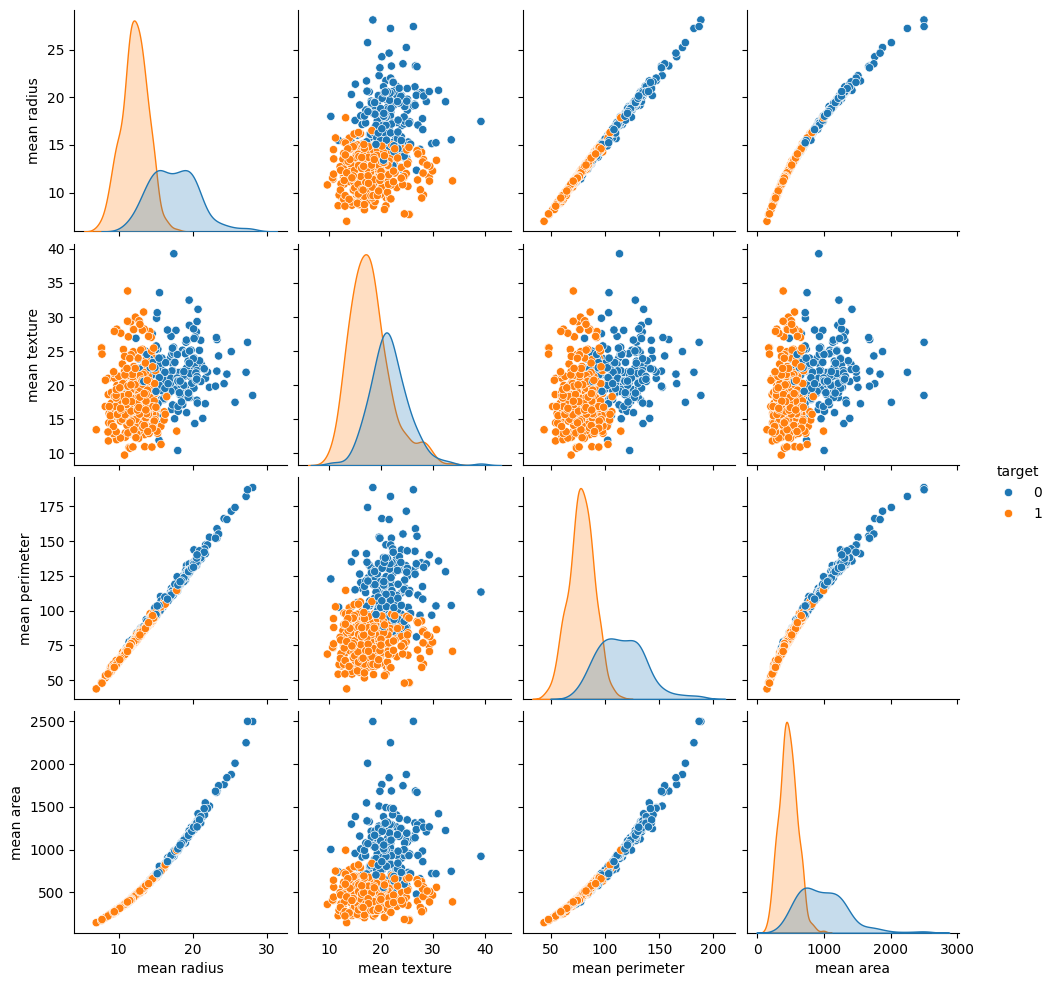

In [14]:
from sklearn.datasets import load_breast_cancer
breast = load_breast_cancer()
features = pd.DataFrame(breast.data, columns=breast.feature_names)
target = pd.Series(breast.target)
exemplo_f = features.columns[:4]

def pPlot(X, y):
  X["target"] = y
  sns.pairplot(X, hue="target")
  plt.show()

pPlot(features[exemplo_f], target)

**Bins Fixos**

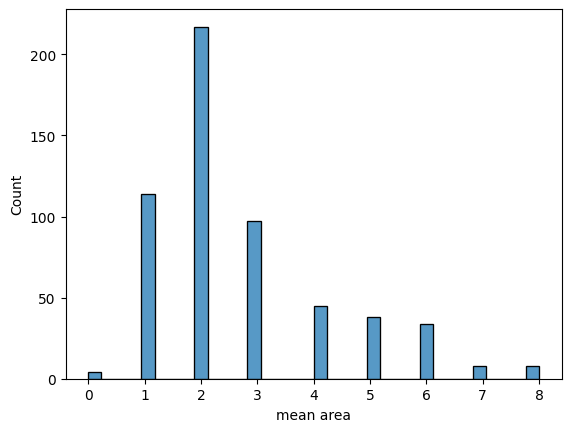

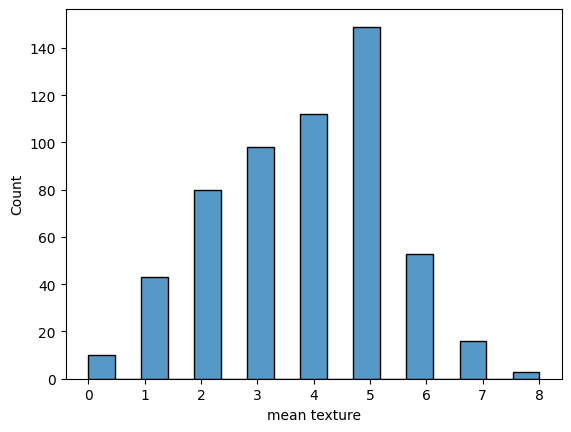

In [15]:
feature_1  = features["mean area"]
feature_2 = features["mean texture"]

f_b_1 = [100, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 2000]
f_b_2 = [10, 12, 14, 16, 18, 20, 24, 28, 30, 32]

sns.histplot(pd.cut(feature_1, bins=f_b_1, labels=False))
plt.show()
sns.histplot(pd.cut(feature_2, bins=f_b_2, labels=False))
plt.show()

**Bins Variaveis**

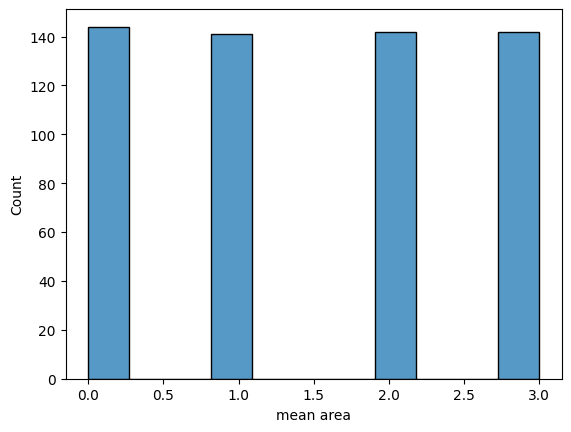

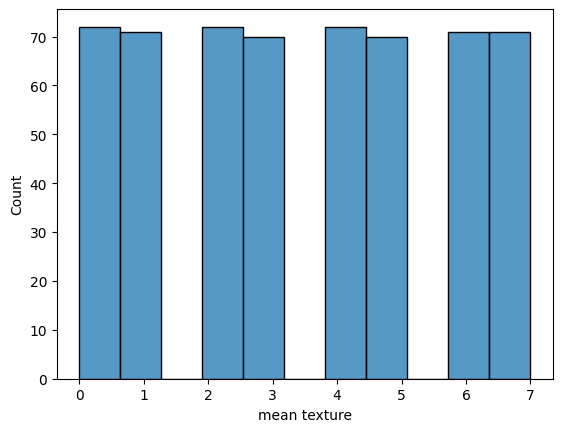

In [16]:
#dividindo em quartos
sns.histplot(pd.qcut(feature_1, q=4, labels=False))
plt.show()
#dividindo em oitavos
sns.histplot(pd.qcut(feature_2, q=8, labels=False))
plt.show()

# 3 - Transformer no Breast Cancer

Function Transformer

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_function_transformer.py:210: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(


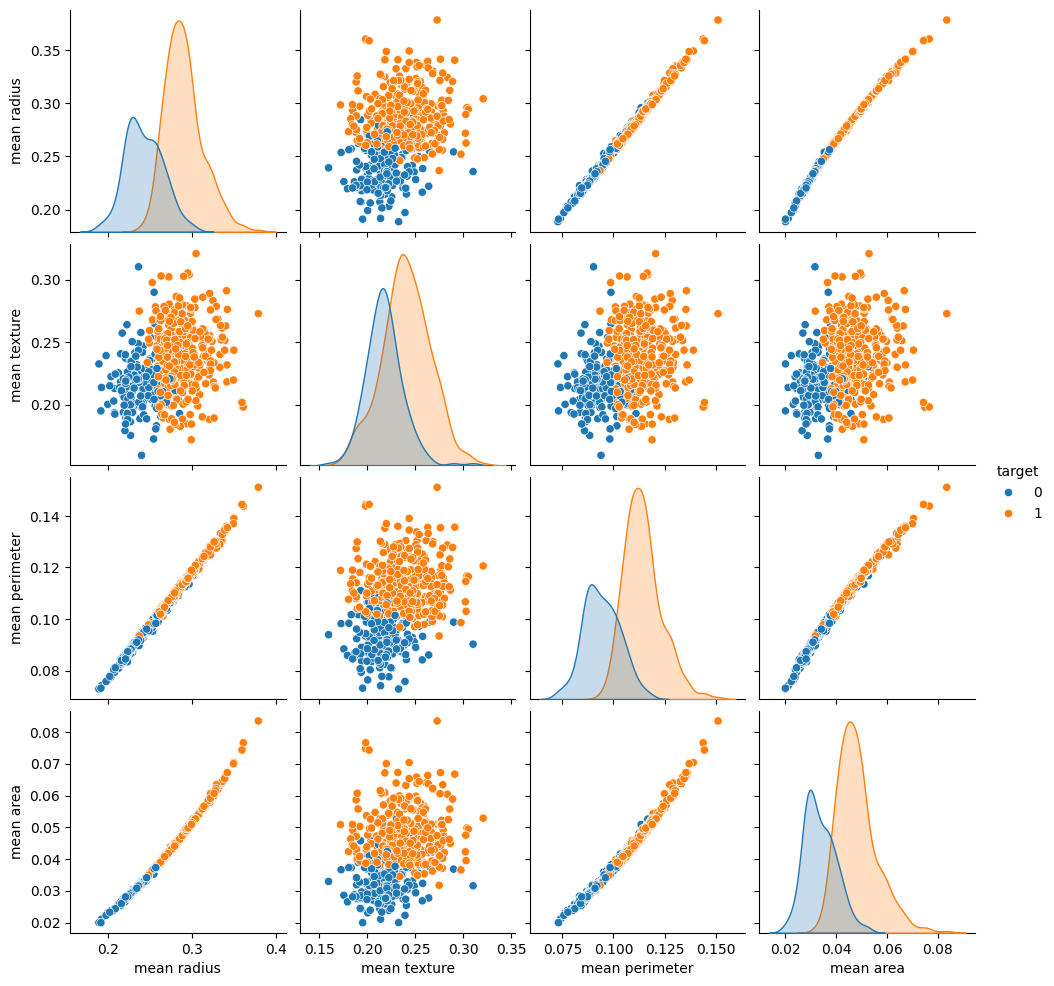

In [17]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import FunctionTransformer

#ele transforma o valor na raiz quadrado do seu inverso
def sqrtInv(X):
  return 1/ np.sqrt(X)
def sqrtInvInverso(X):
  return np.sqrt(1/X)


func_transformer = FunctionTransformer(sqrtInv, inverse_func=sqrtInvInverso)

pPlot(func_transformer.fit_transform(features)[exemplo_f], target)

Power Transformer

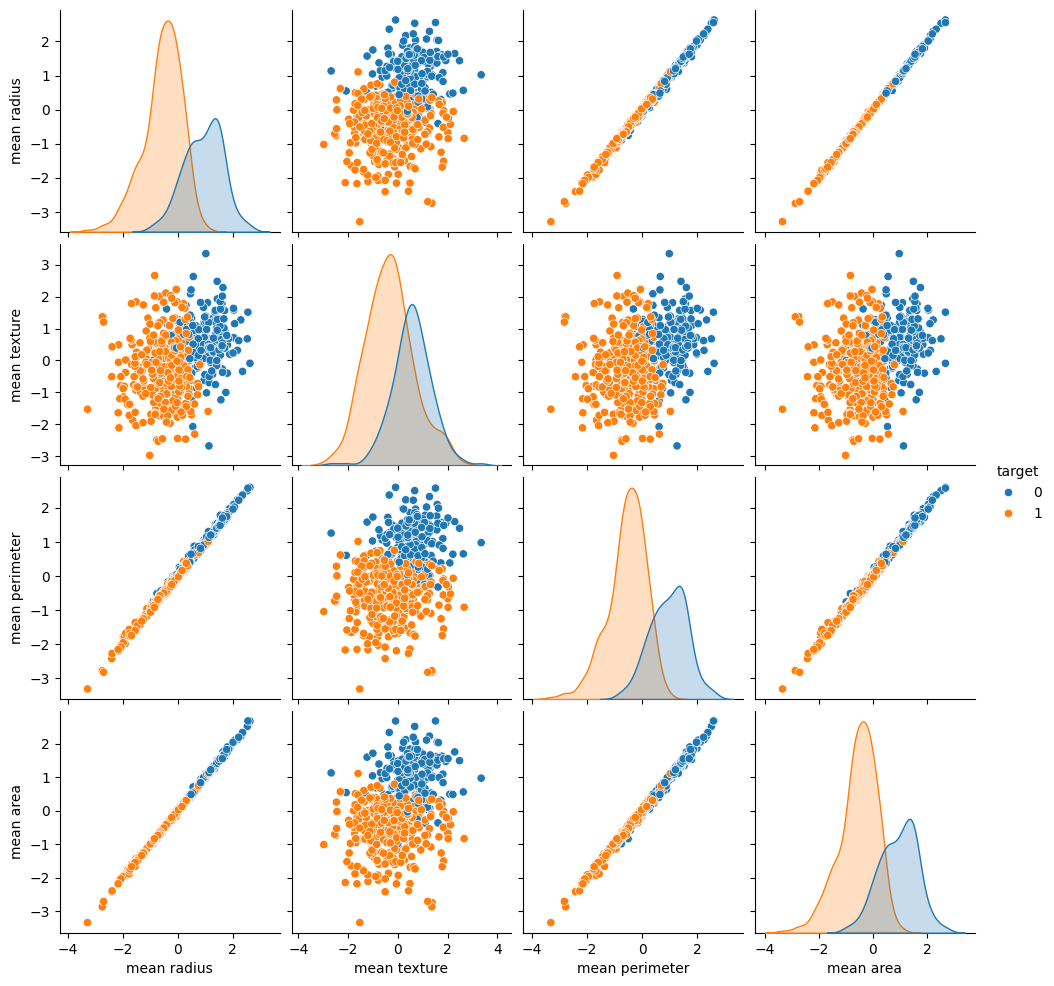

In [18]:
from sklearn.preprocessing import PowerTransformer

power = PowerTransformer(method='yeo-johnson')

pPlot(pd.DataFrame(power.fit_transform(features), columns=breast.feature_names)[exemplo_f], target)

# 4 - Scaler no Breast Cancer

É possível aplicar tanto o StandardScaler quanto o MinMaxScaler:

- StandardScaler: padroniza os dados com média 0 e desvio padrão 1 (mais gaussiano).
- MinMaxScaler: normaliza os dados para o intervalo [0, 1].

O problema é quando aplicamos a normalização L2 pois ele desconsidera o resto da base dos dados e foca em cada instancia individualmente para que a soma de cada uma de suas features seja igual a 1. Como o intervalo de valores ja é minimo em cada instancia, qualquer modificação altera drasticamente a sua posição no espaço vetorial.

MinMax

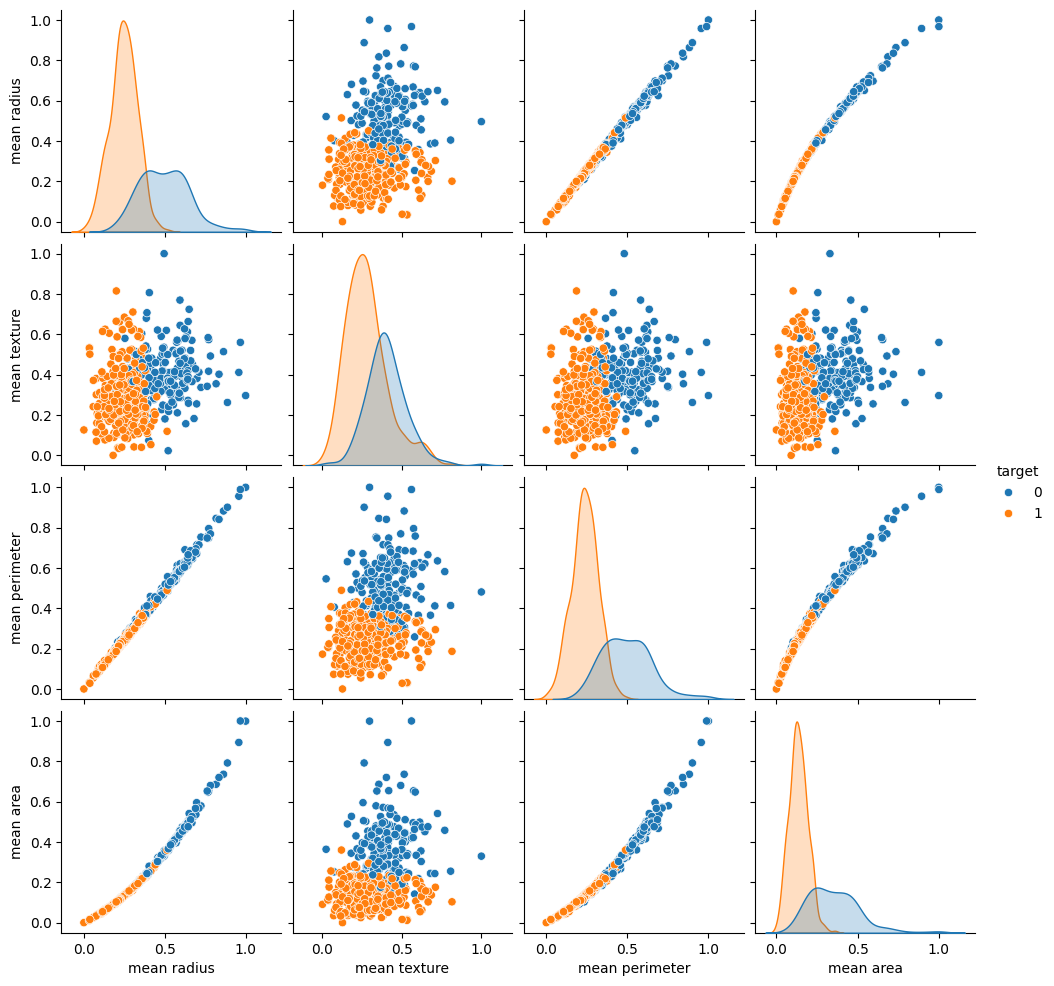

In [19]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

pPlot(pd.DataFrame(minmax.fit_transform(features), columns=breast.feature_names)[exemplo_f], target)

Standard

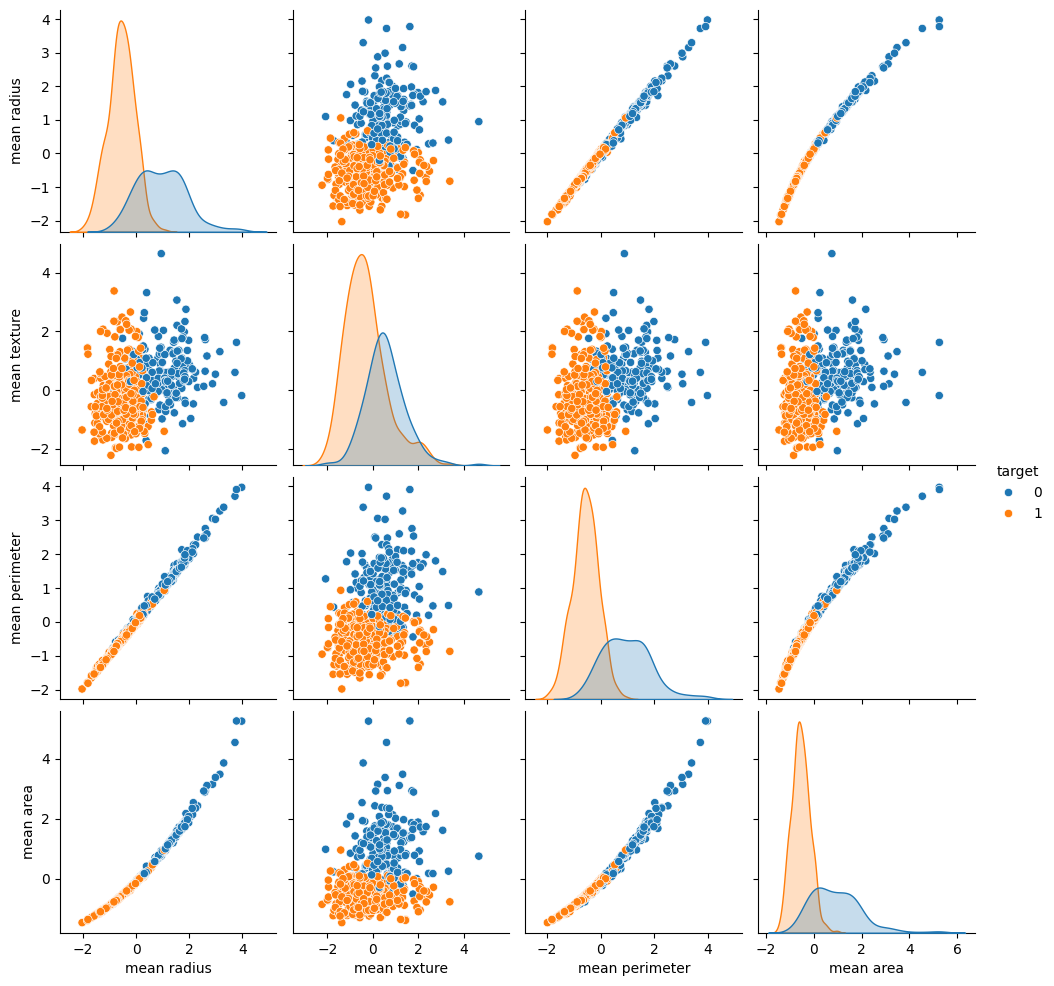

In [20]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

pPlot(pd.DataFrame(std.fit_transform(features), columns=breast.feature_names)[exemplo_f], target)

L2 Normalização

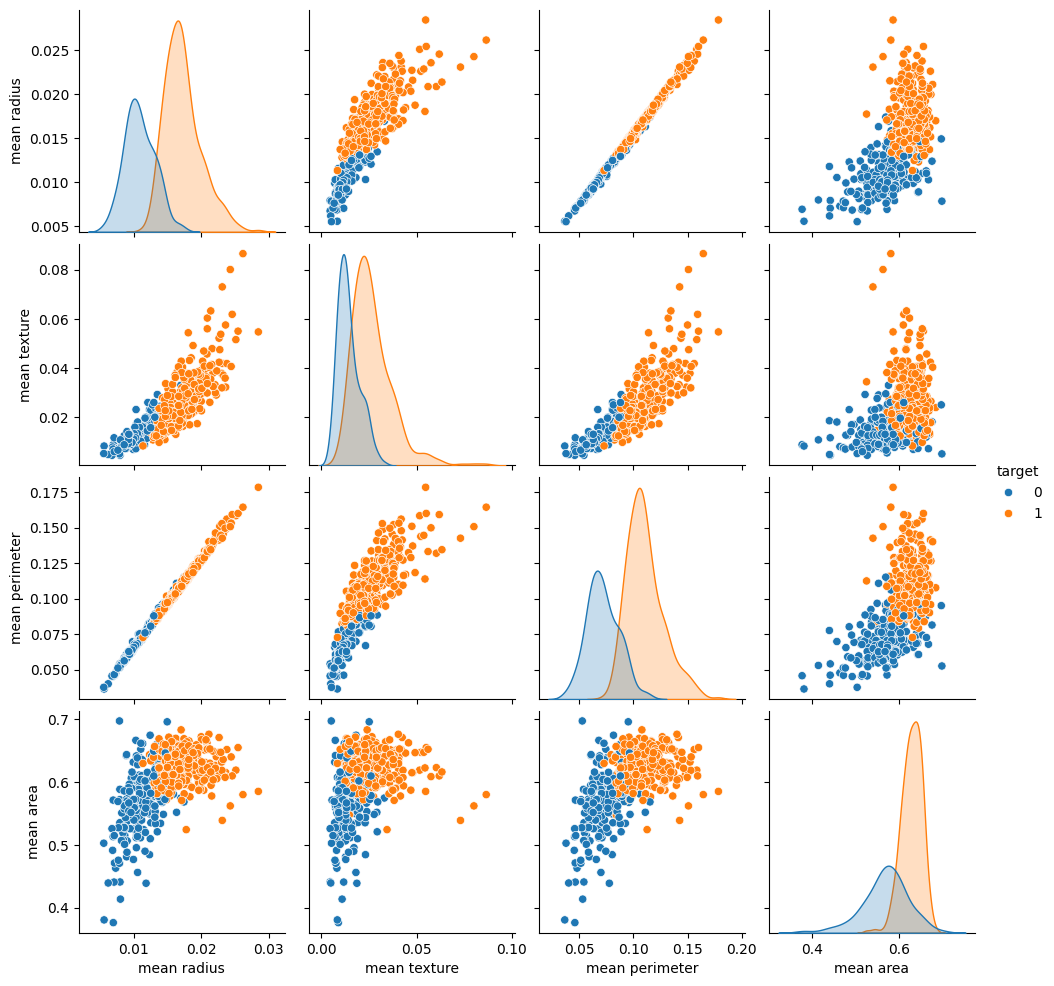

In [21]:
from sklearn.preprocessing import normalize

pPlot(pd.DataFrame(normalize(features, norm='l2'), columns=breast.feature_names)[exemplo_f], target)

Aplicando os 3

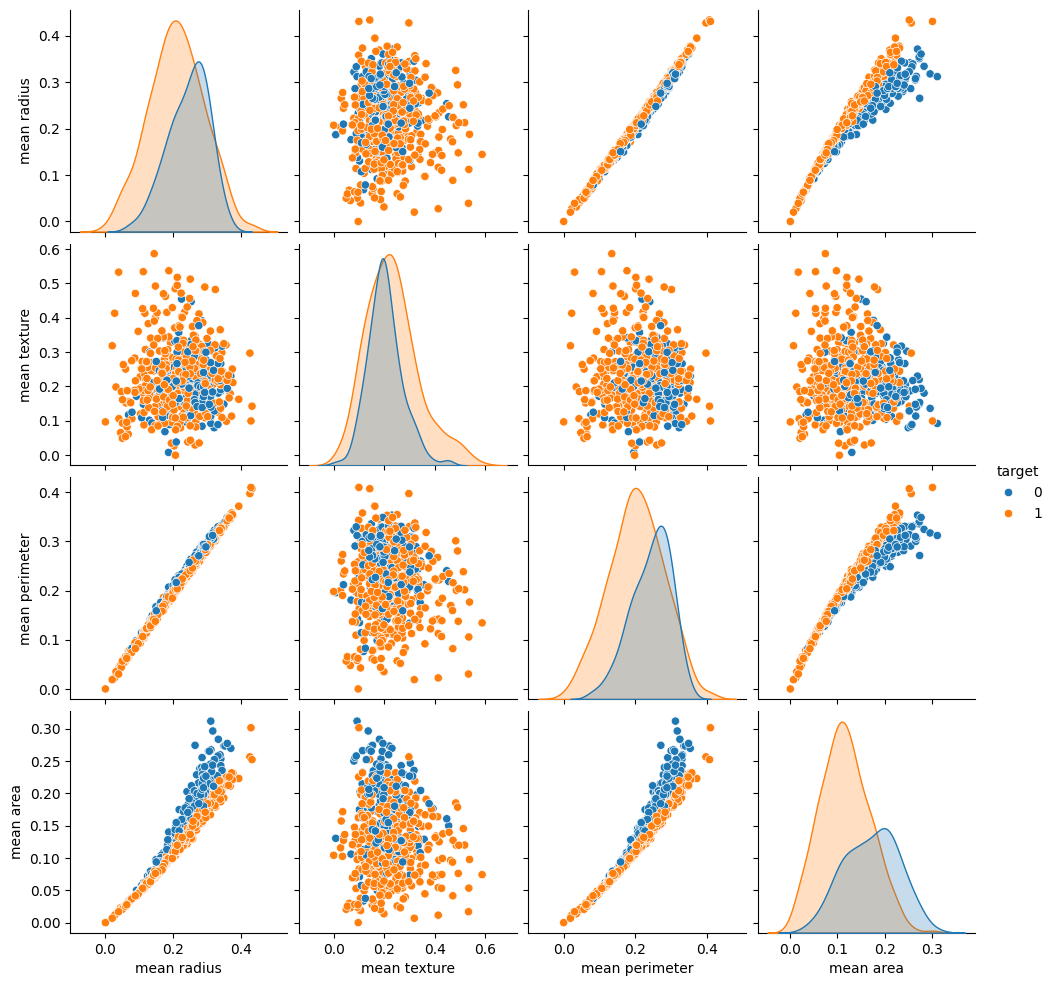

In [22]:
cobaia = features
cobaia  = normalize( minmax.fit_transform ( std.fit_transform ( cobaia ) ), norm='l2' )
pPlot(pd.DataFrame(cobaia, columns=breast.feature_names)[exemplo_f], target)

# 5 - Large Movie e Processamento Gramatico

Para facilitar o uso dos dados, os arquivos foram organizados assim:

- `train_pos.txt`: todos os exemplos positivos de treino concatenados.
- `train_neg.txt`: todos os exemplos negativos de treino concatenados.
- `test_pos.txt`: todos os exemplos positivos de teste concatenados.
- `test_neg.txt`: todos os exemplos negativos de teste concatenados.


In [23]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt_tab')

STOP_WORDS = stopwords.words('english')

def getTextData(arquivo):
  with open(arquivo, 'r') as f:
    docs = f.read().replace("<br />", "\n").split("<sep>")  #tirar <br>
    return docs

def mountDataset(tipo):
  pos = pd.DataFrame(getTextData(tipo+"_pos.txt"), columns=["texto"])
  pos["target"] = 1
  neg = pd.DataFrame(getTextData(tipo+"_neg.txt"), columns=["texto"])
  neg["target"] = 0
  return pd.concat([pos, neg])

mountDataset("train")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,texto,target
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1
...,...,...
12495,"Towards the end of the movie, I felt it was to...",0
12496,This is the kind of movie that my enemies cont...,0
12497,I saw 'Descent' last night at the Stockholm Fi...,0
12498,Some films that you pick up for a pound turn o...,0


In [24]:
def removeStopWords(docs):
    linhas = []
    for doc in docs:
      doc_word = word_tokenize(doc) #tokenizar
      doc = " ".join([word for word in doc_word if word.lower() not in STOP_WORDS])
      linhas.append(doc.strip())

    return linhas

data_stopword = removeStopWords(mountDataset("train")["texto"].to_list())
data_stopword

["Bromwell High cartoon comedy . ran time programs school life , `` Teachers '' . 35 years teaching profession lead believe Bromwell High 's satire much closer reality `` Teachers '' . scramble survive financially , insightful students see right pathetic teachers ' pomp , pettiness whole situation , remind schools knew students . saw episode student repeatedly tried burn school , immediately recalled ......... .......... High . classic line : INSPECTOR : 'm sack one teachers . STUDENT : Welcome Bromwell High . expect many adults age think Bromwell High far fetched . pity n't !",
 "Homelessness ( Houselessness George Carlin stated ) issue years never plan help street considered human everything going school , work , vote matter . people think homeless lost cause worrying things racism , war Iraq , pressuring kids succeed , technology , elections , inflation , worrying 'll next end streets . given bet live streets month without luxuries home , entertainment sets , bathroom , pictures wal

In [25]:
def stemWords(docs):
    linhas = []
    for doc in docs:
      doc_word = word_tokenize(doc) #tokenizar
      stem = PorterStemmer()
      doc = " ".join([stem.stem(word) for word in doc_word])
      linhas.append(doc.strip())

    return linhas

data_stem = stemWords(data_stopword)
data_stem

["bromwel high cartoon comedi . ran time program school life , `` teacher `` . 35 year teach profess lead believ bromwel high 's satir much closer realiti `` teacher `` . scrambl surviv financi , insight student see right pathet teacher ' pomp , petti whole situat , remind school knew student . saw episod student repeatedli tri burn school , immedi recal ......... .......... high . classic line : inspector : 'm sack one teacher . student : welcom bromwel high . expect mani adult age think bromwel high far fetch . piti n't !",
 "homeless ( houseless georg carlin state ) issu year never plan help street consid human everyth go school , work , vote matter . peopl think homeless lost caus worri thing racism , war iraq , pressur kid succeed , technolog , elect , inflat , worri 'll next end street . given bet live street month without luxuri home , entertain set , bathroom , pictur wall , comput , everyth treasur see 's like homeless ? goddard bolt 's lesson . mel brook ( direct ) star bolt 

In [26]:
nltk.download('wordnet')
nltk.download('omw-1.4')
def lemmaWords(docs):
    linhas = []
    for doc in docs:
      doc_word = word_tokenize(doc) #tokenizar
      lemma = WordNetLemmatizer()
      doc = " ".join([lemma.lemmatize(word) for word in doc_word])
      linhas.append(doc.strip())

    return linhas

data_lemma = lemmaWords(data_stopword)
data_lemma

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


["Bromwell High cartoon comedy . ran time program school life , `` Teachers `` . 35 year teaching profession lead believe Bromwell High 's satire much closer reality `` Teachers `` . scramble survive financially , insightful student see right pathetic teacher ' pomp , pettiness whole situation , remind school knew student . saw episode student repeatedly tried burn school , immediately recalled ......... .......... High . classic line : INSPECTOR : 'm sack one teacher . STUDENT : Welcome Bromwell High . expect many adult age think Bromwell High far fetched . pity n't !",
 "Homelessness ( Houselessness George Carlin stated ) issue year never plan help street considered human everything going school , work , vote matter . people think homeless lost cause worrying thing racism , war Iraq , pressuring kid succeed , technology , election , inflation , worrying 'll next end street . given bet live street month without luxury home , entertainment set , bathroom , picture wall , computer , eve

Vetorização Bag-of-Words

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=5)
pd.DataFrame(vectorizer.fit_transform(data_stem).toarray(), columns =vectorizer.get_feature_names_out())

,00,000,007,01,02,03,04,05,06,07,...,zoot,zorro,zu,zucco,zucker,zuckerman,zulu,zuniga,zwick,émigré
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24998,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Vetorização Bag-of-Ngrams

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=5, ngram_range=(3,4))
pd.DataFrame(vectorizer.fit_transform(data_lemma).toarray(), columns =vectorizer.get_feature_names_out())

,000 year ago,000 year old,10 10 movie,10 10 star,10 15 minute,10 bethany cox,10 entertainment 10,10 instead 10,10 items less,10 line minimum,...,young woman whose,younger brother hank,yvonne de carlo,zelah clarke jane,zelah clarke timothy,zelah clarke timothy dalton,zero character development,zombie look like,zombie make up,zorro fighting legion
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 6 - Large Movie TF-IDF e Regressão Logistica

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_vec2 = TfidfVectorizer(min_df=5, ngram_range=(3,4))

X_lemma = tf_vec2.fit_transform(data_lemma)

tf_data2 = pd.DataFrame({
    'feature': tf_vec2.get_feature_names_out(),
    'idf': tf_vec2.idf_
}).sort_values(by='idf', ascending=False)

print("Maiores e menores IDF")
print(tf_data2.head(10), "\n------\n", tf_data2.tail(10))

Maiores e menores IDF
                      feature       idf
8210         young girl whose  9.334912
6         10 entertainment 10  9.334912
8208            young girl go  9.334912
8205        yet still managed  9.334912
8203          yet come across  9.334912
14              10 quality 10  9.334912
12             10 minute long  9.334912
7               10 instead 10  9.334912
4216  maybe missing something  9.334912
4214            maybe ll like  9.334912 
------
                  feature       idf
2004      film ever made  6.096233
5387     one worst movie  6.026805
4759  movie ve ever seen  6.020726
4762       movie ve seen  5.973380
4758       movie ve ever  5.917185
5443        over the top  5.879647
4408     movie ever made  5.828354
4414     movie ever seen  5.558327
7929    worst movie ever  5.484764
7371        ve ever seen  4.844404


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

y = mountDataset("train")["target"]

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_lemma, y)

test_set = mountDataset("test") #criando set de teste
X_test = tf_vec2.transform( lemmaWords(removeStopWords(test_set["texto"])) )
y_test = test_set["target"]

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.58      0.65     12500
           1       0.63      0.79      0.70     11258

    accuracy                           0.68     23758
   macro avg       0.69      0.68      0.68     23758
weighted avg       0.69      0.68      0.68     23758



Maiores e menores coeficientes


<ipython-input-31-3473688998>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='word', y='coef', data=pd.concat([coef_data.head(10), coef_data.tail(10)]), palette='icefire')


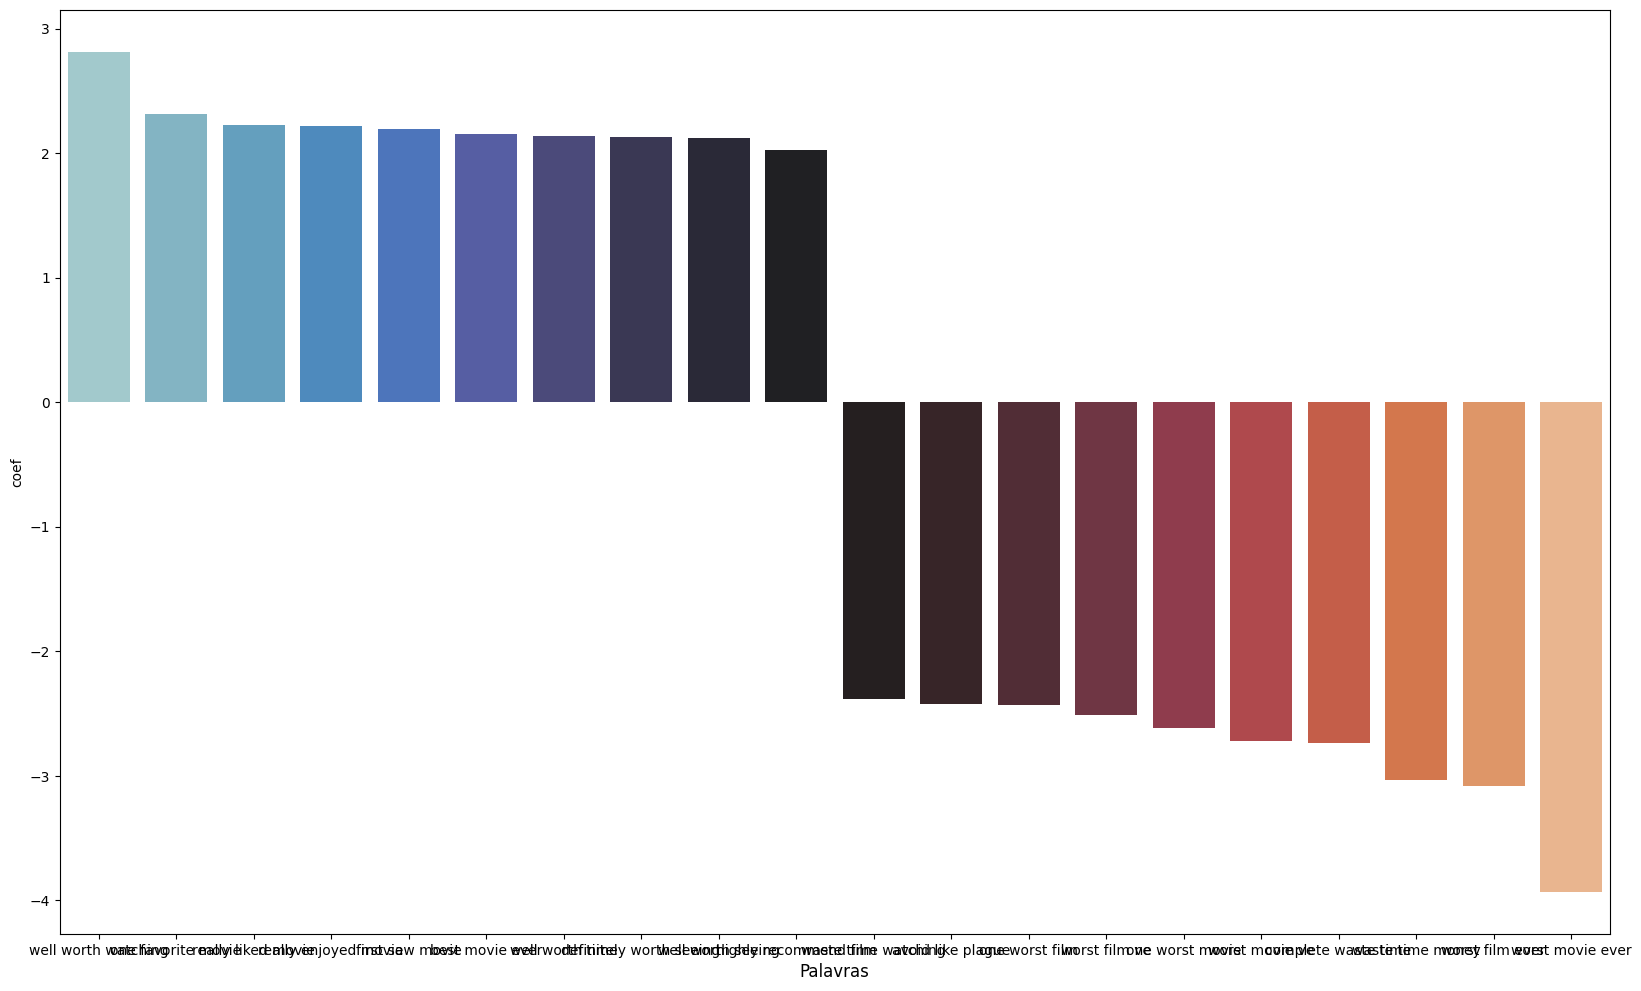

                         word      coef
7765      well worth watching  2.813630
5205       one favorite movie  2.313669
5933       really liked movie  2.226328
5898     really enjoyed movie  2.215354
2345          first saw movie  2.192750
641           best movie ever  2.151102
7761          well worth time  2.137982
1305  definitely worth seeing  2.124967
7759        well worth seeing  2.121359
3057    highly recommend film  2.022666 
------
                      word      coef
7591  waste time watching -2.379737
434     avoid like plague -2.420003
5383       one worst film -2.430008
7921        worst film ve -2.513647
5387      one worst movie -2.615579
7936       worst movie ve -2.719416
1100  complete waste time -2.735432
7582     waste time money -3.035726
7914      worst film ever -3.080870
7929     worst movie ever -3.930782


In [31]:
coef_data = pd.DataFrame({'word': tf_vec2.get_feature_names_out(), 'coef': log_reg.coef_[0]}).sort_values(by='coef', ascending=False)
print("Maiores e menores coeficientes")
plt.figure(figsize=(20, 12))
sns.barplot(x='word', y='coef', data=pd.concat([coef_data.head(10), coef_data.tail(10)]), palette='icefire')
plt.xlabel("Palavras", fontsize=12)
plt.show()
print(coef_data.head(10), "\n------\n", coef_data.tail(10))

# 7 - Encoding do Powerlifting

In [32]:
import kagglehub
import pandas as pd

pl_path = kagglehub.dataset_download("dansbecker/powerlifting-database")

pl_data = pd.read_csv(pl_path + "/openpowerlifting.csv")
pl_data = pl_data.sample(10000)

One-Hot Encoding

In [33]:
categorias = ["Sex", "Equipment", "Division", "Name"]
pd.get_dummies(pl_data[categorias]).astype(int)

,Sex_F,Sex_M,Equipment_Multi-ply,Equipment_Raw,Equipment_Single-ply,Equipment_Straps,Equipment_Wraps,Division_-100kg,Division_12*13,Division_13-15,...,Name_Øystein Indergård,Name_Øystein Løndalen,Name_Øyvind Askeland,Name_Øyvind Haugrav,Name_Øyvind Karlsen,Name_Øyvind Kvakkestad,Name_Øyvind Opdal Olufsen,Name_Øyvind Reitbakken,Name_Øyvind Sanders,Name_Šaban Saud
273336,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
235907,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
289168,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
263320,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14314,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135293,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78310,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
47173,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
262092,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Dummy Encoding

In [34]:
categorias = ["Sex", "Equipment", "Division", "Name"]
pd.get_dummies(pl_data[categorias], drop_first=True).astype(int)

,Sex_M,Equipment_Raw,Equipment_Single-ply,Equipment_Straps,Equipment_Wraps,Division_12*13,Division_13-15,Division_13-15 Junior Men,Division_16-17,Division_16-18 Junior Men,...,Name_Øystein Indergård,Name_Øystein Løndalen,Name_Øyvind Askeland,Name_Øyvind Haugrav,Name_Øyvind Karlsen,Name_Øyvind Kvakkestad,Name_Øyvind Opdal Olufsen,Name_Øyvind Reitbakken,Name_Øyvind Sanders,Name_Šaban Saud
273336,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
235907,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
289168,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
263320,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14314,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135293,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78310,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
47173,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
262092,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Effect Encoding

In [46]:
effect_encoded = pd.DataFrame()

for cat in categorias:
  pl_cat_data = pd.get_dummies(pl_data[cat]).astype(int)

  for i, linha in pl_cat_data.iterrows():
      if linha.sum() == 0: #se todos valores tão zerados
          pl_cat_data.loc[i] = -1
  effect_encoded = pd.concat([effect_encoded, pl_cat_data], axis=1)

#effect_encoded = effect_encoded.astype(int)
effect_encoded

,F,M,Multi-ply,Raw,Single-ply,Straps,Wraps,-100kg,12*13,13-15,...,Øystein Indergård,Øystein Løndalen,Øyvind Askeland,Øyvind Haugrav,Øyvind Karlsen,Øyvind Kvakkestad,Øyvind Opdal Olufsen,Øyvind Reitbakken,Øyvind Sanders,Šaban Saud
273336,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
235907,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
289168,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
263320,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14314,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135293,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78310,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
47173,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
262092,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


A diferença com o Effect Encoding e o resto é que ele converte todos dummies de uma categoria em -1 se estiverem zerados, para não afetar o calculo dos coeficientes durante o treinamento do modelo.

# 8 - Hashing e Bin Counting do Powerlifting

Feature Hashing

In [49]:
from sklearn.feature_extraction import FeatureHasher
hasher = FeatureHasher(len(categorias))
pd.DataFrame.sparse.from_spmatrix(hasher.transform(pl_data[categorias].to_dict(orient='records')), columns=categorias)

,Sex,Equipment,Division,Name
0,1.0,0,-1.0,0
1,-1.0,2.0,-1.0,0
2,0,0,0,0
3,1.0,1.0,0,0
4,0,0,0,2.0
...,...,...,...,...
9995,0,1.0,0,1.0
9996,-2.0,0,1.0,1.0
9997,1.0,1.0,0,0
9998,-1.0,1.0,0,0


Bin Counting

In [37]:
from sklearn.preprocessing import KBinsDiscretizer

#target vai ser a colocação do atleta

def getPlace(x):
  try:
    return int(x)
  except:
    return -1

bin_counted_data = pl_data.copy()
target = bin_counted_data["Place"].map(getPlace)

bin_counted_data = bin_counted_data.drop(columns=categorias + ["MeetID", "Place"])

for coluna in bin_counted_data.columns:
    means = target.groupby(pl_data[coluna]).mean()
    bin_counted_data[coluna] = pl_data[coluna].map(means)

bin_counted_data["Place"] = target
bin_counted_data.fillna(0, inplace=True)
bin_counted_data

,Age,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Wilks,Place
273336,0.000000,8.500000,2.040000,0.0,2.938776,0.0,3.331034,0.0,2.450000,3.117647,30.0,30
235907,0.000000,1.250000,1.068702,0.0,0.000000,0.0,2.000000,0.0,2.238095,4.000000,4.0,4
289168,4.805970,5.888889,4.043299,0.0,2.882353,0.0,2.478261,0.0,1.958904,2.388889,4.0,4
263320,4.100000,1.461538,2.708440,0.0,0.000000,0.0,2.529412,0.0,0.000000,2.777778,1.0,1
14314,1.966667,3.333333,2.547445,0.0,2.643836,0.0,2.398148,0.0,2.205479,1.882353,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
135293,0.000000,1.666667,2.547445,0.0,4.230769,0.0,2.812500,0.0,2.250000,3.000000,1.0,1
78310,0.000000,3.461538,2.494964,0.0,3.000000,0.0,2.064220,0.0,1.954545,3.466667,4.5,1
47173,4.457831,6.000000,4.043299,0.0,2.500000,0.0,1.722222,0.0,2.642857,2.285714,3.0,3
262092,0.000000,1.600000,2.788902,0.0,3.057692,0.0,2.816667,0.0,2.460317,2.740741,1.0,1


# 9 - Projeção Linear

A projeção linear consiste em tornar um ponto colinear com a reta de outro vetor. Isso equivale a projetar um vetor em um subespaço de menor dimensão.

Exemplo: Um ponto X em um espaço 2D projetado sobre a reta de V, reduz sua dimensionalidade para 1D.

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*AzQxlw0Ul3UgugW3HW3pIA.png">
(https://medium.com/@vladimirmikulik/why-linear-regression-is-a-projection-407d89fd9e3a)

No caso de projeção 3D para 2D (como ao renderizar objetos 3D em telas 2D):

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*64E5oeBsbmopIr8C">
(https://skannai.medium.com/projecting-3d-points-into-a-2d-screen-58db65609f24)

Esse conceito é base para a redução de dimensionalidade em datasets com múltiplas features.


O PCA (Principal Component Analysis) aplica esse conceito com os seguintes passos:

1. Centraliza os dados (média de cada feature = 0)
2. Calcula a matriz de covariância
3. Extrai os componentes principais (direções de maior variância)
4. Ordena os componentes e projeta os dados no novo espaço vetorial de menor dimensão


# 10 - Lung Cancer e PCA

In [38]:
import kagglehub
import pandas as pd

lung_path = kagglehub.dataset_download("shantanugarg274/lung-cancer-prediction-dataset")

lung_data = pd.read_csv(lung_path + "/Lung Cancer Dataset.csv")
lung_data

100%|██████████| 127k/127k [00:00<00:00, 52.3MB/s]

Extracting files...


,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,32,0,1,1,0,0,1,60.700696,1,1,1,1,94.012495,0,1,1,0,YES
4996,80,0,1,1,1,1,1,50.751741,0,1,1,1,94.394968,0,0,0,0,YES
4997,51,1,0,0,1,0,0,61.063496,1,0,0,0,98.108901,0,0,0,1,NO
4998,76,1,0,1,0,0,0,48.662872,0,1,0,1,95.577773,1,0,0,0,NO


Variancia: [0.10965579 0.10523939]


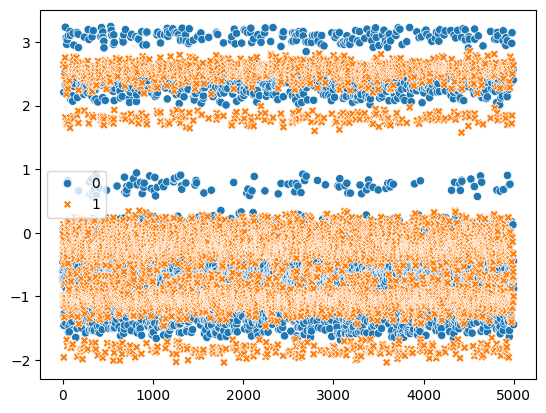

Influencia das features nos componentes


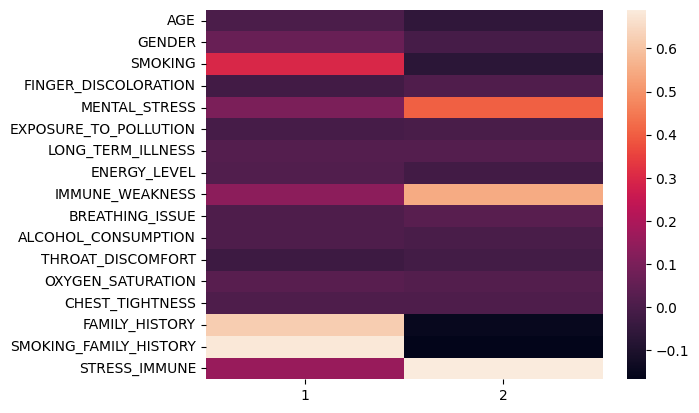

Curva de Carga


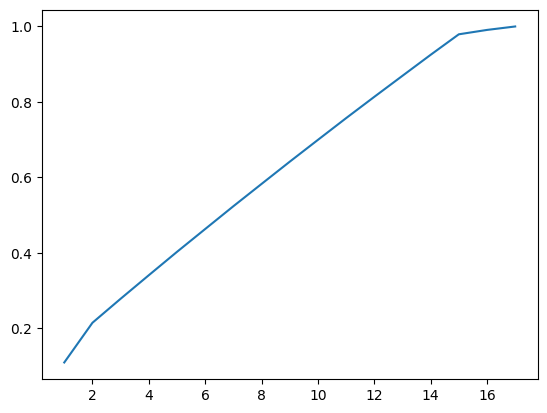

In [50]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer as Scaler

target = lung_data["PULMONARY_DISEASE"]
features = lung_data.drop(columns="PULMONARY_DISEASE")

pca_pipeline = Pipeline([
    ("scaler", Scaler()),
    ("pca", PCA(n_components=2))
])

pca_pipeline.fit(features)

pca_components = pca_pipeline.named_steps["pca"].components_

print("Variancia:", pca_pipeline.named_steps["pca"].explained_variance_ratio_)

sns.scatterplot(pca_pipeline.transform(features))
plt.show()

components_lung = pd.DataFrame(
    pca_components.T,
    index=features.columns,
    columns=range(1, pca_components.shape[0]+1)
)

print("Influencia das features nos componentes")
sns.heatmap(components_lung) #colaboração de cada feature no calculo dos componentes
plt.show()

pca_pipeline = Pipeline([
    ("scaler", Scaler()),
    ("pca", PCA())
])

pca_pipeline.fit(features)

cum_var = np.cumsum( pca_pipeline.named_steps["pca"].explained_variance_ratio_ )

print("Curva de Carga")
plt.plot(range(1, len(cum_var) + 1), cum_var) #curva de carga
plt.show()

# 11 - PCA, Whitening e Curva de Carga

O Whitening é uma etapa opcional que pode ser aplicada após o PCA.

Ele transforma os componentes principais para terem escala unitária e correlação nula entre si

Isso ajuda a resolver problemas de colinearidade, mas pode aumentar o ruído.

Para escolher o número ideal de componentes:

1. Itere sobre N componentes
2. Calcule a variância explicada cumulativa

A variância mostra a distancia que os componentes estão da informação original

Quando plotamos esses valores, ou seja, a curva de carga, o ideal é que tentamos achar o menor valor de X possível que possa render a melhor variância cumulativa, ou a “ponta do joelho” nesse gráfico.

<img src="https://saturncloud.io/images/blog/variance_ratio_plot.webp">
(https://saturncloud.io/blog/what-is-sklearn-pca-explained-variance-and-explained-variance-ratio-difference/)


# 12 - Problemas do PCA

O PCA possui um péssimo desempenho por depender do SVD e chega a demorar um tempo polinomial cúbico de tempo para considerar todos os dados. Isso também torna ele um péssimo candidato para modelos iterativos que sempre estão se atualizando, pois os componentes precisam ser recalculados para acomodar os novos dados.


Muitas vezes os componentes não devolvem nenhuma informação inerentemente útil ou óbvia e são difíceis de interpretar.
Valores subjetivos como visualizações, replays, clicks, vendas no mês, movimento de loja que dependem de outras variáveis, geralmente interpretativas e culturais, podem levar a resultados distorcidos com o PCA.
